# 04 – Model Interpretation

Use SHAP `TreeExplainer` on the trained XGBoost model to explain predictions globally and for individual customers.

Inputs (from `03_modeling.ipynb`):
- `data/processed/test.csv`
- `models/xgboost.joblib`

Outputs:
- `reports/figures/shap_summary.png` – global feature importance
- `reports/figures/shap_waterfall_1.png` – high-risk customer
- `reports/figures/shap_waterfall_2.png` – low-risk customer
- `reports/figures/shap_waterfall_3.png` – borderline customer
- `reports/figures/architecture_diagram.png` – pipeline overview

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import shap

ROOT = Path("..")
FIGURES_DIR = ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load model and test data

In [2]:
xgb = joblib.load(ROOT / "models" / "xgboost.joblib")

test  = pd.read_csv(ROOT / "data" / "processed" / "test.csv")
X_test = test.drop(columns=["Churn"])
y_test = test["Churn"]

print(f"Test set: {X_test.shape}  |  Churn rate: {y_test.mean():.3f}")

Test set: (1409, 45)  |  Churn rate: 0.265


## 2. SHAP values – 300 test rows

In [3]:
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_test), size=300, replace=False)
X_sample = X_test.iloc[sample_idx].reset_index(drop=True)

explainer   = shap.TreeExplainer(xgb)
shap_values = explainer(X_sample)

print("SHAP values shape:", shap_values.values.shape)

SHAP values shape: (300, 45)


## 3. Global summary plot

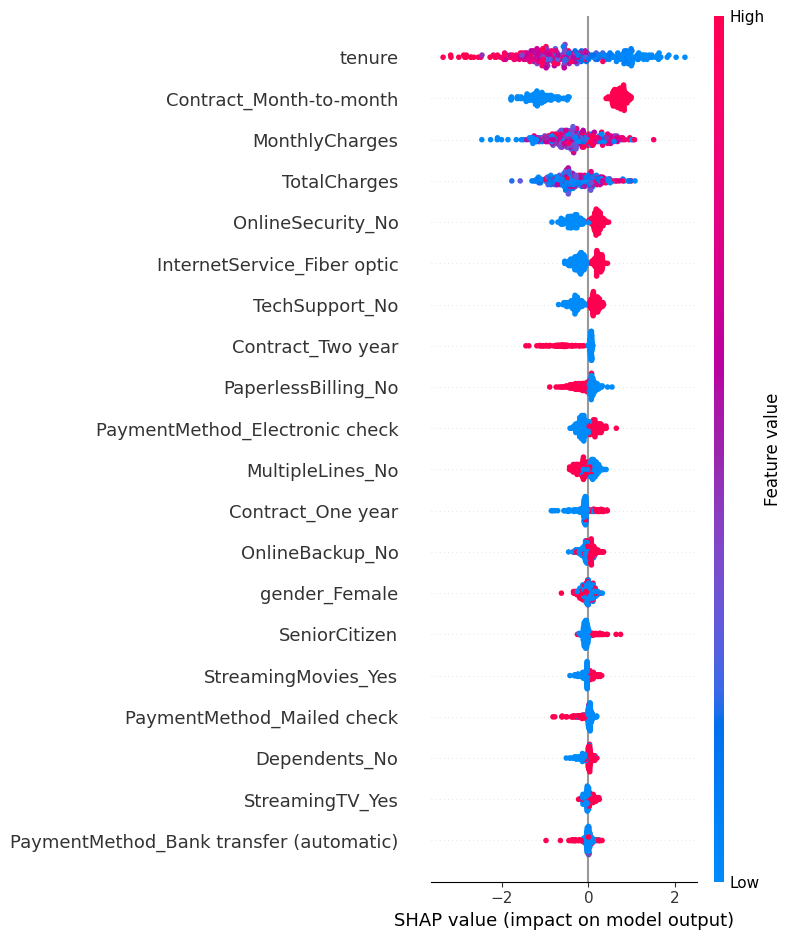

Saved shap_summary.png


In [4]:
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False, max_display=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved shap_summary.png")

## 4. Select three customers – high / low / borderline risk

In [5]:
proba_all = xgb.predict_proba(X_test)[:, 1]

idx_high   = int(proba_all.argmax())
idx_low    = int(proba_all.argmin())
idx_border = int(np.abs(proba_all - 0.5).argmin())

cases = [
    (idx_high,   "High-risk",    1),
    (idx_low,    "Low-risk",     2),
    (idx_border, "Borderline",   3),
]

for idx, label, _ in cases:
    print(f"{label:12s}  row={idx:4d}  P(churn)={proba_all[idx]:.4f}  actual={y_test.iloc[idx]}")

High-risk     row=1259  P(churn)=0.9965  actual=1
Low-risk      row=1344  P(churn)=0.0000  actual=0
Borderline    row= 560  P(churn)=0.4990  actual=0


## 5. Waterfall plots for individual customers

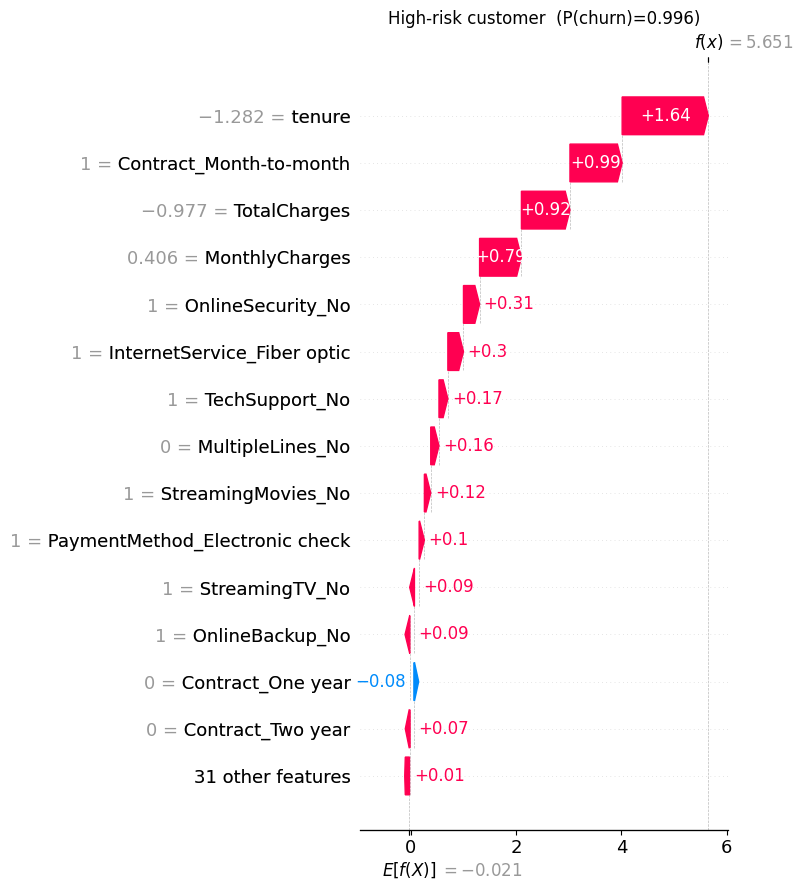

Saved shap_waterfall_1.png


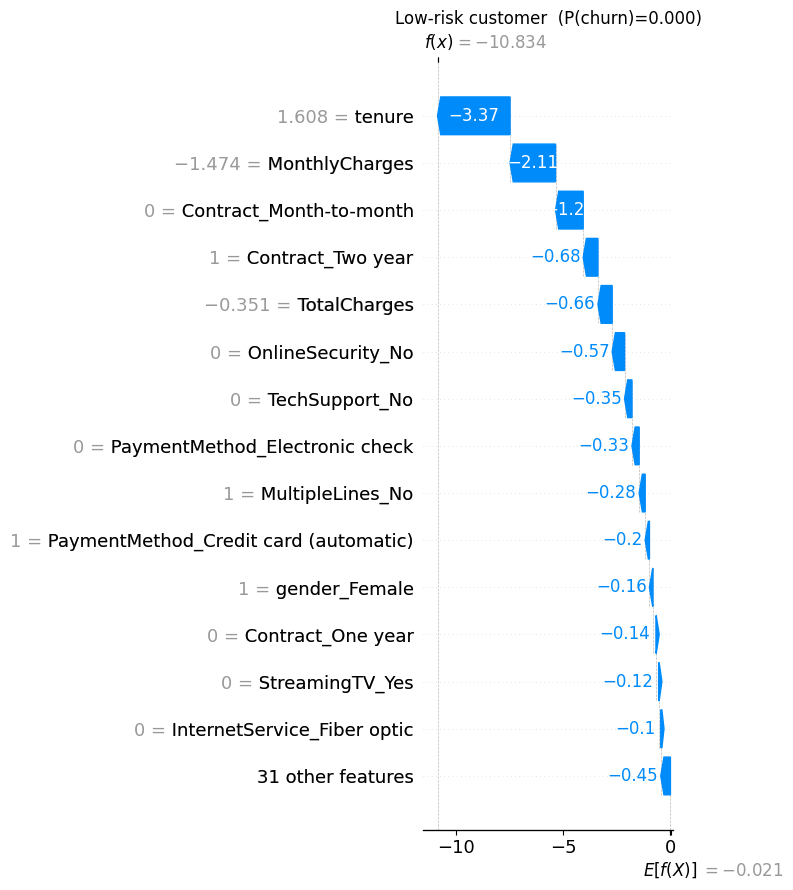

Saved shap_waterfall_2.png


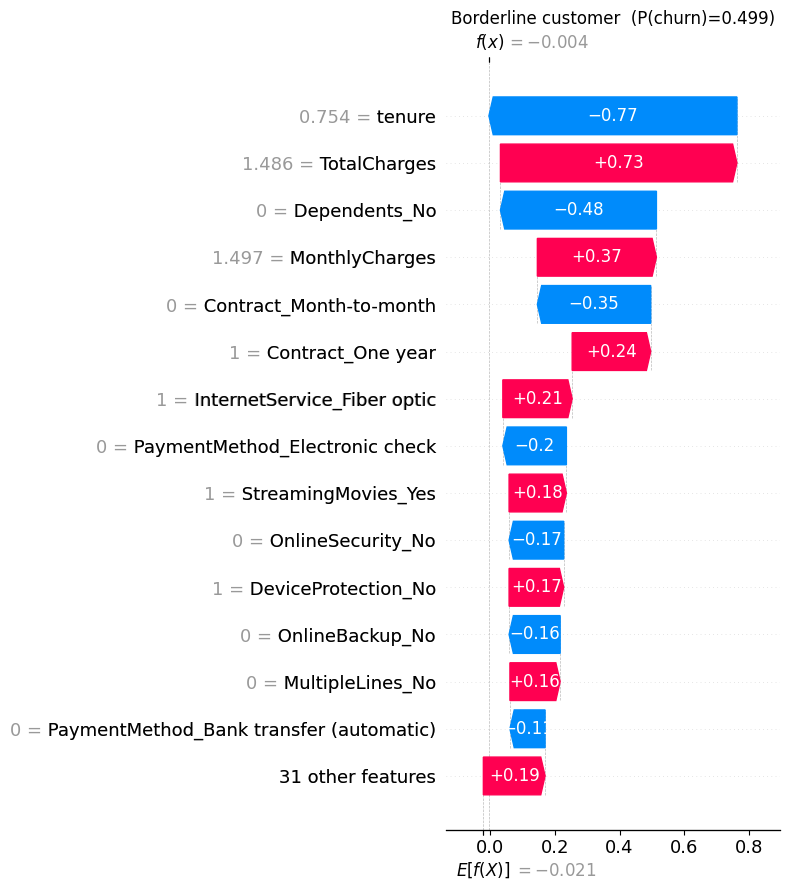

Saved shap_waterfall_3.png


In [6]:
for idx, label, num in cases:
    sv = explainer(X_test.iloc[[idx]])
    plt.figure()
    shap.plots.waterfall(sv[0], max_display=15, show=False)
    plt.title(f"{label} customer  (P(churn)={proba_all[idx]:.3f})")
    plt.tight_layout()
    out_path = FIGURES_DIR / f"shap_waterfall_{num}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {out_path.name}")

## 6. Architecture / pipeline diagram

A schematic of the end-to-end ML pipeline: raw data → preprocessing → model training → interpretation → Streamlit app.

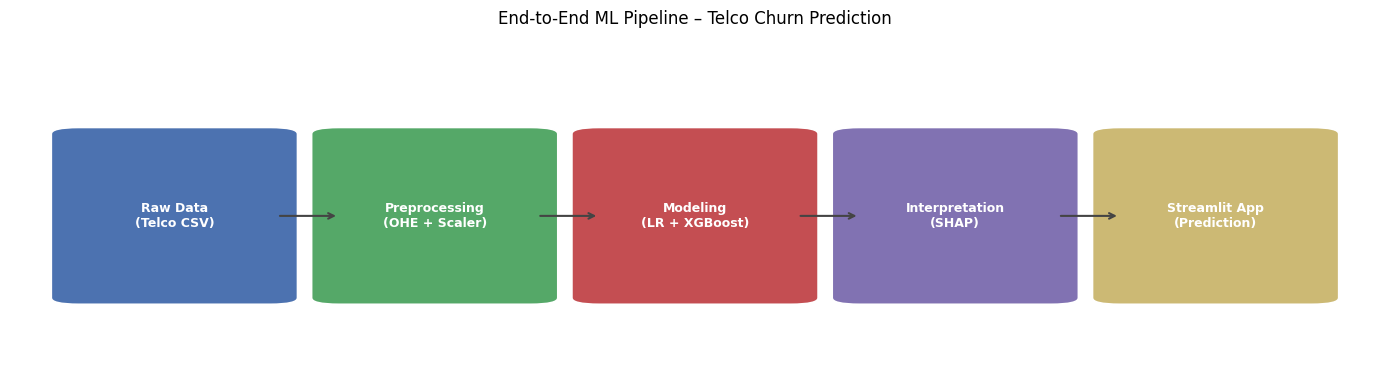

Saved architecture_diagram.png


In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis("off")

stages = [
    ("Raw Data\n(Telco CSV)",         "#4C72B0"),
    ("Preprocessing\n(OHE + Scaler)", "#55A868"),
    ("Modeling\n(LR + XGBoost)",      "#C44E52"),
    ("Interpretation\n(SHAP)",        "#8172B2"),
    ("Streamlit App\n(Prediction)",   "#CCB974"),
]

n      = len(stages)
box_w  = 0.14
box_h  = 0.5
gap    = (1.0 - n * box_w) / (n + 1)

for i, (label, color) in enumerate(stages):
    x = gap + i * (box_w + gap)
    rect = mpatches.FancyBboxPatch(
        (x, 0.25), box_w, box_h,
        boxstyle="round,pad=0.02",
        facecolor=color, edgecolor="white", linewidth=1.5,
        transform=ax.transAxes, clip_on=False,
    )
    ax.add_patch(rect)
    ax.text(
        x + box_w / 2, 0.5, label,
        ha="center", va="center", fontsize=9,
        color="white", fontweight="bold",
        transform=ax.transAxes,
    )
    if i < n - 1:
        arrow_x = x + box_w + 0.005
        ax.annotate(
            "",
            xy=(arrow_x + gap - 0.005, 0.5),
            xytext=(arrow_x, 0.5),
            xycoords="axes fraction",
            arrowprops=dict(arrowstyle="->", color="#444", lw=1.5),
        )

ax.set_title("End-to-End ML Pipeline – Telco Churn Prediction", fontsize=12, pad=20)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "architecture_diagram.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved architecture_diagram.png")

## 7. Key takeaways

From the SHAP summary plot the most influential features driving churn are:

| Rank | Feature | Direction |
|------|---------|----------|
| 1 | `tenure` | Long tenure → lower churn risk |
| 2 | `Contract_Month-to-month` | Month-to-month → higher churn risk |
| 3 | `TotalCharges` | Higher charges → associated with longer tenure, lower risk |
| 4 | `InternetService_Fiber optic` | Fiber optic → higher churn risk |
| 5 | `MonthlyCharges` | High monthly charges → higher churn risk |

The waterfall plots show that individual predictions are dominated by a small subset of these features, confirming the model's focus on contract type and tenure.